<div dir="rtl">

# تحلیل ریسک و بازده پرتفوی با Python

در این تحلیل بازده و ریسک سه سهام بزرگ تکنولوژی را
برای سال‌های 2023 تا 2025 بررسی می‌کنیم.

</div>

In [16]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

<div dir="rtl">
## دریافت داده‌ها
</div>

In [17]:
tickers = ['AAPL', 'MSFT', 'GOOGL']
data = yf.download(tickers, start='2023-01-01', end='2025-12-31')['Close']
data.head(10)

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOGL,MSFT
Date,,,
2023-01-03,122.982719,88.336708,232.948273
2023-01-04,124.251183,87.305840,222.758377
2023-01-05,122.933556,85.442368,216.156326
2023-01-06,127.456787,86.572342,218.703735
2023-01-09,127.977936,87.246368,220.833160
2023-01-10,128.548248,87.642853,222.515259
2023-01-11,131.262238,90.715607,229.243729
2023-01-12,131.183548,90.329025,231.907883
2023-01-13,132.510986,91.310333,232.607956


<div dir="rtl">
##بازده روزانه
</div>

In [18]:
returns = data.pct_change().dropna()
returns.head(10)

Ticker,AAPL,GOOGL,MSFT
Date,,,
2023-01-04,0.010314,-0.011670,-0.043743
2023-01-05,-0.010605,-0.021344,-0.029638
2023-01-06,0.036794,0.013225,0.011785
2023-01-09,0.004089,0.007786,0.009737
2023-01-10,0.004456,0.004544,0.007617
2023-01-11,0.021113,0.035060,0.030238
2023-01-12,-0.000599,-0.004261,0.011621
2023-01-13,0.010119,0.010864,0.003019
2023-01-17,0.008756,-0.009010,0.004682


<div dir="rtl">
##نمودار بازده تجمعی
</div>

<Figure size 1200x600 with 0 Axes>

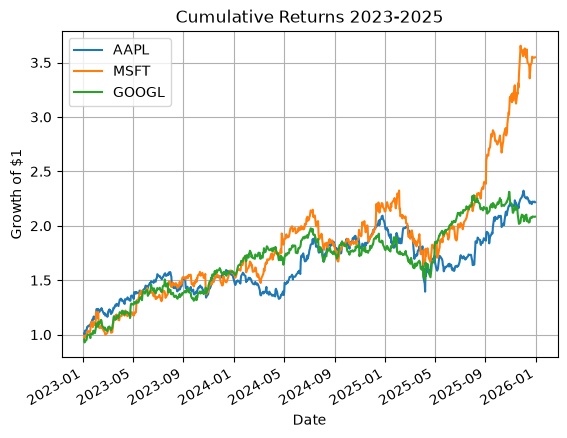

In [19]:
cumulative = (1 + returns).cumprod()
plt.figure(figsize=(12, 6))
cumulative.plot()
plt.title('Cumulative Returns 2023-2025')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend(['AAPL', 'MSFT', 'GOOGL'])
plt.grid(True)
plt.show()

<div dir="rtl">
##آمار ریسک و بازده
</div>

In [20]:
annual_return = returns.mean() * 252
annual_risk = returns.std() * (252 ** 0.5)

summary = pd.DataFrame({
    'بازده سالانه': annual_return,
    'ریسک سالانه': annual_risk,
    'شارپ': annual_return / annual_risk
})

print(summary.round(3))

        بازده سالانه  ریسک سالانه   شارپ
Ticker                                  
AAPL           0.300        0.256  1.171
GOOGL          0.472        0.303  1.557
MSFT           0.274        0.232  1.178
